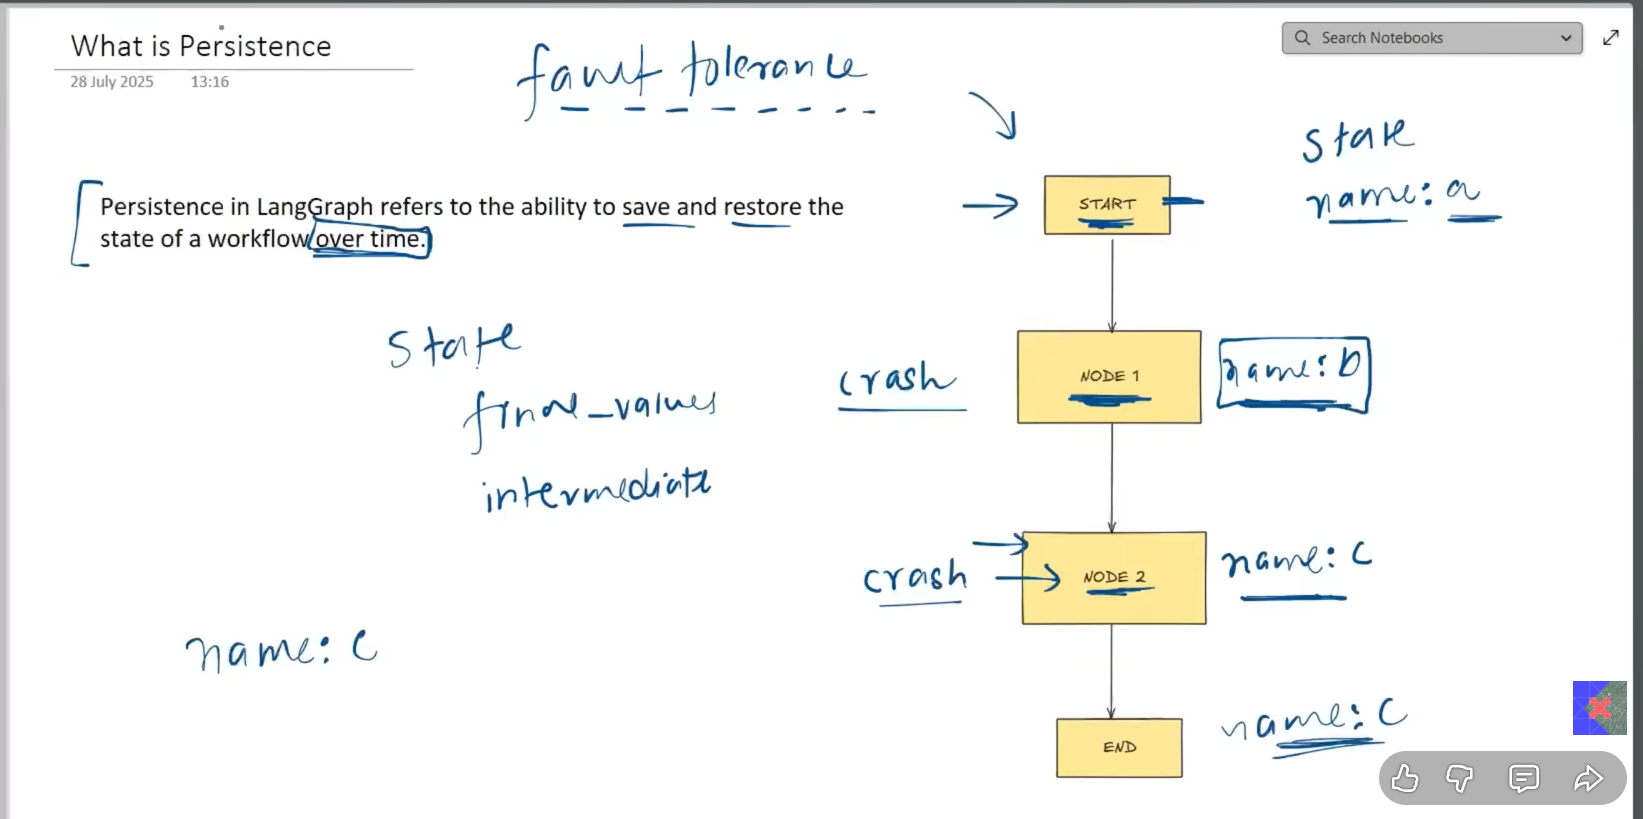

# Superstep in LangGraph

Think of a superstep as one complete step of the agent workflow in LangGraph.

- LangGraph uses graphs to manage AI workflows.

- Each node does something (like calling an LLM, performing a function, or checking a condition).

- A superstep is basically one “tick” where all the nodes that can run, run.

- After a superstep, the graph moves to the next superstep, using the outputs of the previous step.

# Checkpointers in LangGraph

A checkpointer is a way to save the state of your graph at a specific point, so you can resume from there if needed.

- Useful if the workflow is long or might fail.

- Saves all the node outputs and progress.

- You don’t have to start from scratch if something goes wrong.


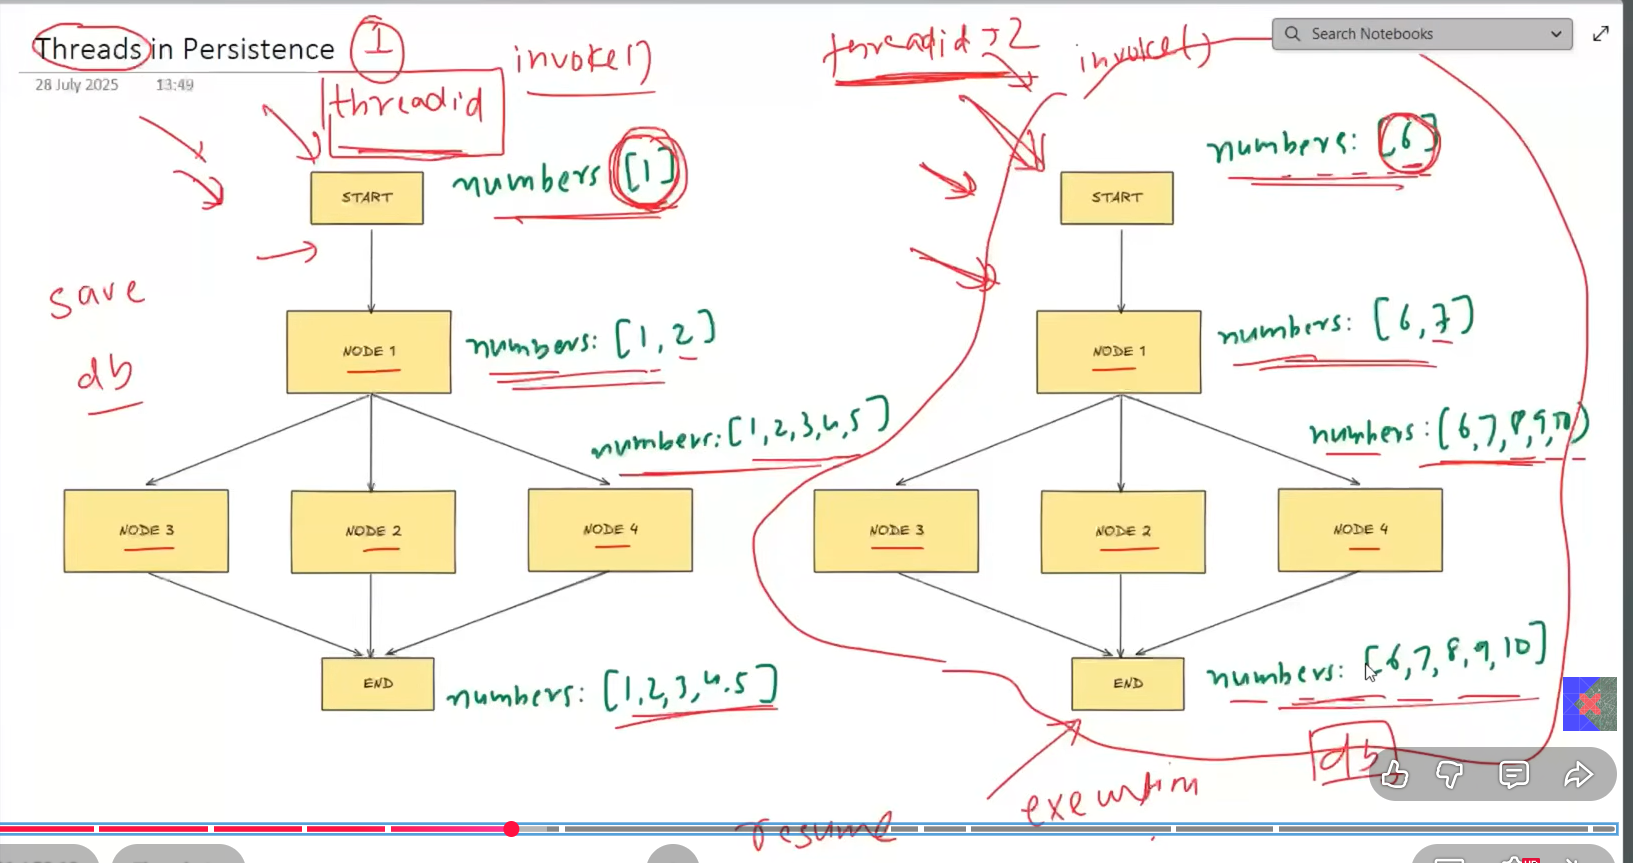


# MemorySaver

- Stores graph state persistently in a more long-term storage, like disk or external DB.
- You can close your program, restart, and still resume.
- Ideal for workflows that are long-running or need to survive crashes.
- Usually used in production or serious experiments.

# InMemorySaver

- Stores graph state only in RAM (memory).
- Once the program stops or crashes, all state is lost.
- Useful for fast testing or debugging, where you don’t need long-term persistence.
- Very fast because it’s all in memory.

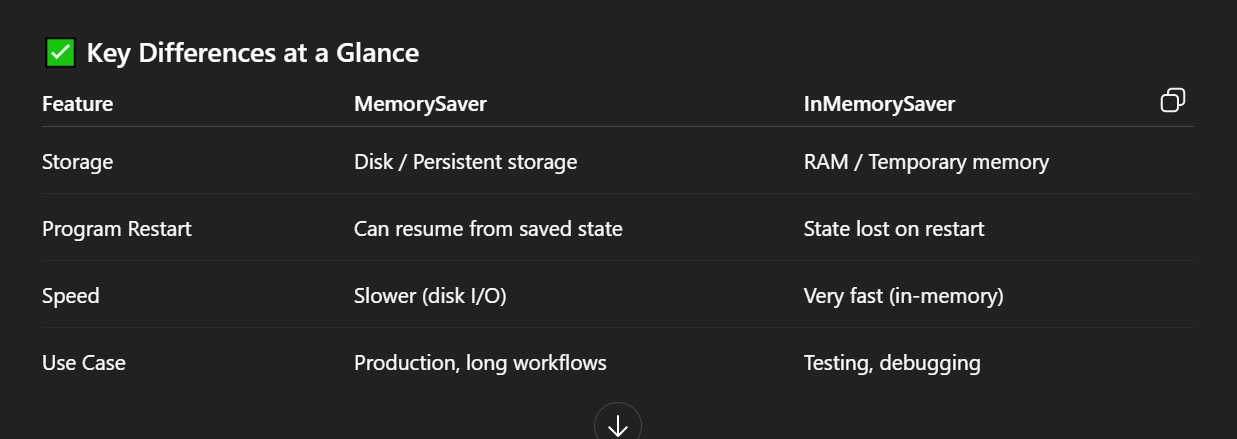
___
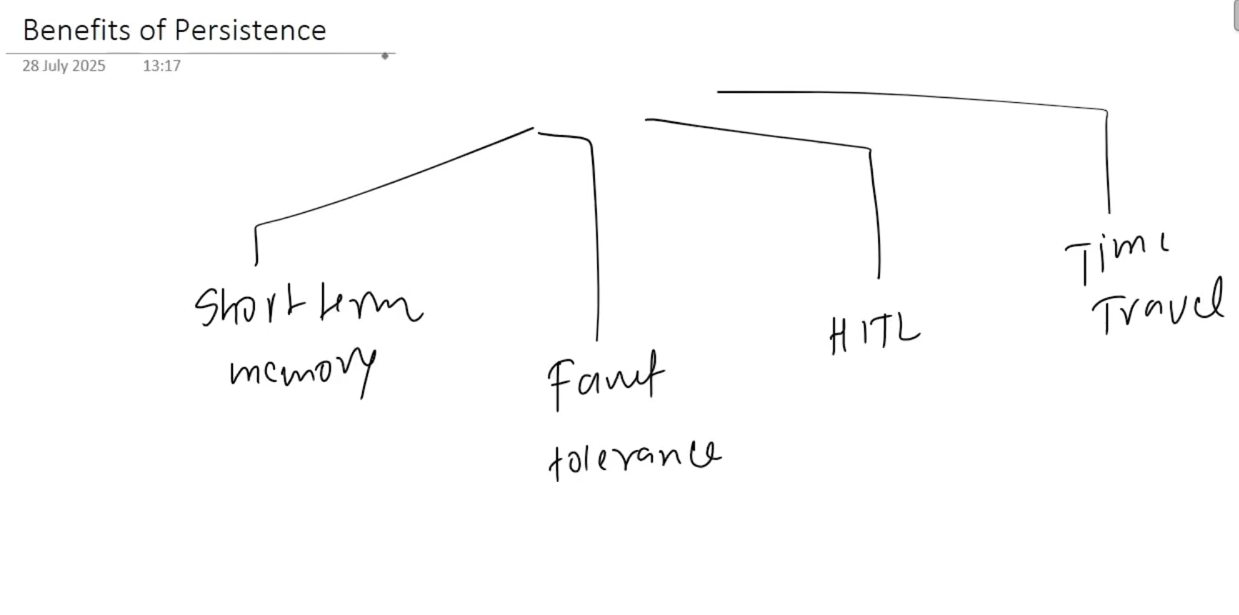

___
# HITL
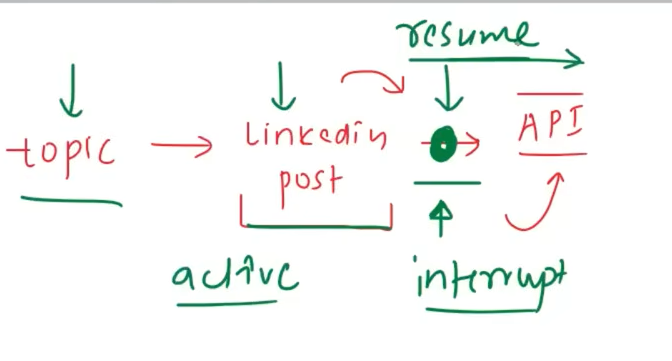

In [16]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
from langgraph.checkpoint.memory import InMemorySaver

In [17]:
load_dotenv()

model = ChatGoogleGenerativeAI(model='gemini-2.5-flash')

In [18]:
class JokeState(TypedDict):
    topic: str
    joke: str
    explaination: str

In [19]:
def generate_joke(state: JokeState):
    topic = state['topic']
    prompt = f"Write a joke on the topic \n **TOPIC**\n {topic}"
    joke = model.invoke(prompt).content
    return {'joke':joke}

def generate_explaination(state: JokeState):
    joke = state['joke']
    prompt = f"Write an explaination for the given joke \n **JOKE**\n {joke}"
    explaination = model.invoke(prompt).content
    return {'explaination': explaination}

In [20]:
graph = StateGraph(JokeState)

# add nodes

graph.add_node('generate_joke', generate_joke)
graph.add_node('generate_explaination', generate_explaination)

graph.add_edge(START, 'generate_joke')
graph.add_edge('generate_joke', 'generate_explaination')
graph.add_edge('generate_explaination', END)

In [21]:
checkpointer = InMemorySaver()
workflow = graph.compile(checkpointer=checkpointer)

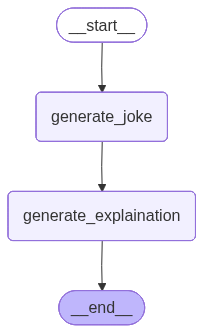

In [32]:
workflow

In [27]:
config1 = {'configurable':{'thread_id': '1'}}
final_state = workflow.invoke({'topic': 'Pizza'}, config=config1)

In [28]:
final_state

{'topic': 'Pizza',
 'joke': 'Why did the pizza tell so many bad jokes?\nBecause it was extra cheesy!',
 'explaination': 'This joke is a classic example of a **pun**, playing on a word with two different meanings:\n\n1.  **Literal Meaning (Pizza):** When we talk about pizza, "extra cheesy" means it has a generous amount of cheese on it. This is usually a desirable quality for pizza lovers.\n\n2.  **Figurative Meaning (Jokes):** In English, the word "cheesy" is also used to describe something that is cheap, corny, unsophisticated, or trying too hard to be impressive or funny, often in a cringeworthy way. "Cheesy jokes" are typically predictable, simplistic, and elicit groans rather than hearty laughter.\n\nThe humor comes from the wordplay that connects these two meanings. The pizza, being literally "extra cheesy" (full of cheese), is humorously depicted as telling jokes that are figuratively "extra cheesy" (corny, predictable, and not very good).\n\nIt\'s a simple, lighthearted pun that

In [29]:
config1 = {'configurable':{'thread_id': '1'}}
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'Pizza', 'joke': 'Why did the pizza tell so many bad jokes?\nBecause it was extra cheesy!', 'explaination': 'This joke is a classic example of a **pun**, playing on a word with two different meanings:\n\n1.  **Literal Meaning (Pizza):** When we talk about pizza, "extra cheesy" means it has a generous amount of cheese on it. This is usually a desirable quality for pizza lovers.\n\n2.  **Figurative Meaning (Jokes):** In English, the word "cheesy" is also used to describe something that is cheap, corny, unsophisticated, or trying too hard to be impressive or funny, often in a cringeworthy way. "Cheesy jokes" are typically predictable, simplistic, and elicit groans rather than hearty laughter.\n\nThe humor comes from the wordplay that connects these two meanings. The pizza, being literally "extra cheesy" (full of cheese), is humorously depicted as telling jokes that are figuratively "extra cheesy" (corny, predictable, and not very good).\n\nIt\'s a simple, l

In [30]:
config2 = {'configurable':{'thread_id': '2'}}
list(workflow.get_state_history(config2))

[StateSnapshot(values={'topic': 'Cricket', 'joke': "Why did the cricket (the insect) get kicked out of the cricket (the sport) commentary box?\n\nBecause he wouldn't stop chirping about how long the Test match was!", 'explaination': 'This joke plays on several layers of wordplay and common knowledge:\n\n1.  **Homonym 1: "Cricket" (Insect) vs. "Cricket" (Sport):**\n    *   The setup introduces a "cricket" (the insect).\n    *   It then places this insect in the context of "cricket" (the sport), specifically in the "commentary box." This immediate juxtaposition of the two meanings of "cricket" is the first humorous element.\n\n2.  **Homonym 2: "Chirping":**\n    *   **Literal Meaning (for the insect):** Crickets (the insects) are famous for making a continuous, high-pitched sound, which we call "chirping."\n    *   **Figurative Meaning (for a human):** When applied to a person, "chirping" can mean talking incessantly, complaining, nattering, or being overly chatty.\n\n3.  **Contextual Hu

# Time Travel

In [33]:
workflow.get_state({"configurable": {"thread_id": "2", "checkpoint_id": "1f0fe890-f96d-6b79-8000-4db7e58a75f8"}})

StateSnapshot(values={'topic': 'Cricket'}, next=('generate_joke',), config={'configurable': {'thread_id': '2', 'checkpoint_id': '1f0fe890-f96d-6b79-8000-4db7e58a75f8'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-01-31T09:41:47.400485+00:00', parent_config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f0fe890-f968-6d5f-bfff-97dcc2963a3d'}}, tasks=(PregelTask(id='4d537ccb-4893-7ddc-f901-2e5cf4ba3777', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result={'joke': "Why did the cricket (the insect) get kicked out of the cricket (the sport) commentary box?\n\nBecause he wouldn't stop chirping about how long the Test match was!"}),), interrupts=())

In [34]:
workflow.invoke(None, {"configurable": {"thread_id": "2", "checkpoint_id": "1f0fe890-f96d-6b79-8000-4db7e58a75f8"}})

{'topic': 'Cricket',
 'joke': 'Why did the cricket team bring a ladder to the game?\n...Because they heard the batsman was going to hit a **six**!',
 'explaination': 'This joke plays on the double meaning of the word "six."\n\n1.  **In Cricket:** When a batsman "hits a six," it means they\'ve hit the ball so powerfully that it flies out of the boundary ropes without bouncing. This instantly scores 6 runs for their team. These shots are often hit very high and very far.\n\n2.  **The Literal Misinterpretation:** The joke humorously pretends that the cricket team misunderstood the phrase. Instead of understanding "hitting a six" as a powerful shot for 6 runs, they\'ve interpreted it literally. They imagine the batsman is going to hit something that *is* a "six" (perhaps the physical number 6, or an object located at a height of six units, like six feet up in the air or on the sixth floor of a building).\n\n3.  **The Punchline:** Since they\'ve literally interpreted "hitting a six" as hitt

# Updating State

In [35]:
workflow.update_state({"configurable": {"thread_id": "2", "checkpoint_id": "1f0fe890-f96d-6b79-8000-4db7e58a75f8", "checkpoint_ns": ""}}, {'topic':'samosa'})

{'configurable': {'thread_id': '2',
  'checkpoint_ns': '',
  'checkpoint_id': '1f0fe8be-09fc-63f7-8001-f397299ef242'}}

In [36]:
list(workflow.get_state_history(config2))

[StateSnapshot(values={'topic': 'samosa'}, next=('generate_joke',), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f0fe8be-09fc-63f7-8001-f397299ef242'}}, metadata={'source': 'update', 'step': 1, 'parents': {}}, created_at='2026-01-31T10:01:57.096139+00:00', parent_config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f0fe890-f96d-6b79-8000-4db7e58a75f8'}}, tasks=(PregelTask(id='4868ce89-a1fb-e07f-5a19-41f0707fb718', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'topic': 'Cricket', 'joke': 'Why did the cricket team bring a ladder to the game?\n...Because they heard the batsman was going to hit a **six**!', 'explaination': 'This joke plays on the double meaning of the word "six."\n\n1.  **In Cricket:** When a batsman "hits a six," it means they\'ve hit the ball so powerfully that it flies out of the boundary ropes

In [38]:
workflow.invoke(None, {"configurable": {"thread_id": "2", "checkpoint_id": "1f0fe8be-09fc-63f7-8001-f397299ef242"}})

{'topic': 'samosa',
 'joke': 'Why did the samosa break up with the pakora?\n\nBecause it had too many **filling** issues!',
 'explaination': 'This joke is a pun that plays on the word "**filling**" and its phonetic similarity to "**feeling issues**."\n\nHere\'s the breakdown:\n\n1.  **Literal Meaning (Food):** A samosa is a fried pastry with a savory **filling** (usually spiced potatoes, peas, and other ingredients). The word "filling" refers to what\'s inside it.\n2.  **Figurative Meaning (Human Relationship):** In human terms, "feeling issues" refers to emotional problems, unresolved emotions, or difficulties in expressing one\'s feelings. These are common reasons for relationships to break up.\n3.  **The Pun:** The joke takes the literal characteristic of the samosa (having a filling) and twists it to sound like a human emotional problem ("feeling issues"). The humor comes from the absurdity of a samosa having emotional baggage that leads to a breakup, all while making a clever play

In [39]:
list(workflow.get_state_history(config2))

[StateSnapshot(values={'topic': 'samosa', 'joke': 'Why did the samosa break up with the pakora?\n\nBecause it had too many **filling** issues!', 'explaination': 'This joke is a pun that plays on the word "**filling**" and its phonetic similarity to "**feeling issues**."\n\nHere\'s the breakdown:\n\n1.  **Literal Meaning (Food):** A samosa is a fried pastry with a savory **filling** (usually spiced potatoes, peas, and other ingredients). The word "filling" refers to what\'s inside it.\n2.  **Figurative Meaning (Human Relationship):** In human terms, "feeling issues" refers to emotional problems, unresolved emotions, or difficulties in expressing one\'s feelings. These are common reasons for relationships to break up.\n3.  **The Pun:** The joke takes the literal characteristic of the samosa (having a filling) and twists it to sound like a human emotional problem ("feeling issues"). The humor comes from the absurdity of a samosa having emotional baggage that leads to a breakup, all while 

# Fault Tolerance

In [40]:
from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import InMemorySaver
from typing import TypedDict
import time
# 1. Define the state
class CrashState(TypedDict):
    input: str
    step1: str
    step2: str
# 2. Define steps
def step_1(state: CrashState) -> CrashState:
    print("✅ Step 1 executed")
    return {"step1": "done", "input": state["input"]}

def step_2(state: CrashState) -> CrashState:
    print("⏳ Step 2 hanging... now manually interrupt from the notebook toolbar (STOP button)")
    time.sleep(1000)  # Simulate long-running hang
    return {"step2": "done"}

def step_3(state: CrashState) -> CrashState:
    print("✅ Step 3 executed")
    return {"done": True}
# 3. Build the graph
builder = StateGraph(CrashState)
builder.add_node("step_1", step_1)
builder.add_node("step_2", step_2)
builder.add_node("step_3", step_3)

builder.set_entry_point("step_1")
builder.add_edge("step_1", "step_2")
builder.add_edge("step_2", "step_3")
builder.add_edge("step_3", END)

checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)



In [41]:
try:
    print("▶️ Running graph: Please manually interrupt during Step 2...")
    graph.invoke({"input": "start"}, config={"configurable": {"thread_id": 'thread-1'}})
except KeyboardInterrupt:
    print("❌ Kernel manually interrupted (crash simulated).")

▶️ Running graph: Please manually interrupt during Step 2...
✅ Step 1 executed
⏳ Step 2 hanging... now manually interrupt from the notebook toolbar (STOP button)
❌ Kernel manually interrupted (crash simulated).


In [ ]:
# 6. Re-run to show fault-tolerant resume
print("\n🔁 Re-running the graph to demonstrate fault tolerance...")
final_state = graph.invoke(None, config={"configurable": {"thread_id": 'thread-1'}})
print("\n✅ Final State:", final_state)
list(graph.get_state_history({"configurable": {"thread_id": 'thread-1'}}))